# PROJET EDP V0

---

# Contexte du projet

## i. Problème étudié

Ce projet porte sur l’étude numérique d’un problème de **contrôle optimal stochastique** issu du problème classique de navigation de Zermelo.

On considère un bateau évoluant dans un domaine bidimensionnel soumis à :
- une vitesse propre contrôlée (choix de direction),
- un champ de vent spatialement variable,
- une perturbation aléatoire modélisée par un bruit brownien.

L’objectif est de déterminer la stratégie optimale permettant d’atteindre une cible en **temps minimal**, tout en tenant compte d’une incertitude sur la dynamique du système.

---

## ii. Modélisation mathématique

La dynamique de la position du bateau $X_t \in \mathbb{R}^2$ est décrite par l’équation différentielle stochastique :

$$
dX_t = b(X_t,\alpha_t)\,dt + \sigma dW_t,
$$

où :
où :
- $ \alpha_t \in [0,2\pi] $ est l’angle de direction choisi par le pilote,
- $ b(x,\alpha) $ représente la vitesse déterministe (vent + propulsion),
- $ \sigma $ est une matrice de diffusion décrivant l’intensité du bruit,
- $ W_t $ est un mouvement brownien bidimensionnel.

Le domaine considéré est un **anneau** :

$$
\Omega = \{(x,y)\in\mathbb{R}^2 \;:\; r^2 < x^2 + y^2 < R^2\}.
$$

Le cercle intérieur constitue la cible, tandis que le cercle extérieur représente une frontière pénalisante.

---

## iii. Fonction valeur et objectif du problème

On cherche à minimiser le coût nécessaire pour atteindre le bord intérieur de l'anneau en partant d'une position donnée x, tout en évitant le bord extérieur.

On définit la fonction valeur :

$$
u(x) = \inf_{\alpha} \sup_{Q} \mathbb{E}\left[\int_0^\tau f(X_t)\,dt + g(X_\tau)\right].
$$

La présence du supremum traduit une approche robuste : on considère le pire cas admissible pour le bruit.

Ainsi, la fonction \( u(x) \) représente le **temps minimal attendu pour atteindre la cible**, sous stratégie optimale.

---

## iv. Équation aux dérivées partielles associée

Grâce au principe de programmation dynamique, la fonction valeur \(u\) est la solution de viscosité unique d’une équation de type **Hamilton–Jacobi–Bellman–Isaacs (HJBI)** :

$$
F(x,u,\nabla u,D^2u) = 0 \quad \text{dans } \Omega,
$$

avec conditions de Dirichlet sur le bord.

Dans ce modèle, l’équation s’écrit explicitement :

$$
-\frac12(\sigma_x^2 u_{xx} + \sigma_y^2 u_{yy})
- v_c(x,y) u_x
+ v_s \|\nabla u\|_2
- \kappa \|\nabla u\|_1
- f(x,y) = 0.
$$

Chaque terme possède une interprétation physique :
- les dérivées secondes correspondent à l’effet du bruit aléatoire,
- le terme de dérivée première traduit l’action du vent,
- les normes du gradient proviennent du problème d’optimisation du contrôle et de l’incertitude robuste.

---

## v. Objectif numérique du projet

Le but du projet est de résoudre numériquement cette EDP à l’aide de deux approches complémentaires :

1. Une méthode par **différences finies**, permettant d’obtenir une solution de référence.
2. Une approche par **réseaux de neurones de type PINNs**, basée sur la minimisation du résidu de l’EDP.

---

### 1 - Approche par différences finies

<u> Principe général</u>

L’objectif est de résoudre numériquement l’équation HJBI associée au problème de navigation optimale présentée plus haut. Cette équation étant définie sur un domaine continu et étant non linéaire, il est nécessaire de la discrétiser afin de la résoudre numériquement.

La méthode des différences finies consiste à remplacer les dérivées de l’équation par des approximations numériques sur une grille discrète du domaine.



<u>Stratégie de maillage</u>

Deux approches sont possibles pour discrétiser le domaine :

- utiliser des coordonnées polaires adaptées à la géométrie en anneau,
- ou englober l’anneau dans un domaine carré et utiliser un maillage cartésien.

Dans ce projet, on adopte la seconde approche, plus simple à mettre en œuvre.

On considère donc un domaine carré :

$$
K = [X_{\min}, X_{\max}] \times [Y_{\min}, Y_{\max}],
$$

qui contient l’anneau $\Omega$.


<u> Discrétisation du domaine</u>

On introduit un maillage cartésien uniforme :

$$
x_i = X_{\min} + i h_x, \quad y_j = Y_{\min} + j h_y,
$$

avec :

$$
h_x = \frac{X_{\max} - X_{\min}}{M+1}, \quad
h_y = \frac{Y_{\max} - Y_{\min}}{M+1}.
$$

Chaque point de la grille est noté $(x_i, y_j)$.

L’inconnue numérique est la matrice :

$$
U = (u_{i,j})_{1 \le i,j \le M},
$$

qui approxime la solution continue :

$$
u_{i,j} \approx u(x_i, y_j).
$$


<u> Définition des différentes zones</u>

Pour chaque point de la grille, on calcule son rayon :

$$
r_{i,j} = \sqrt{x_i^2 + y_j^2}.
$$

On distingue alors trois types de points :

- les points **intérieurs** à l’anneau :

$$
\Omega_{\text{int}} = \{(i,j) : r < r_{i,j} < R\},
$$

- les points du **bord intérieur** :

$$
\Gamma_r = \{(i,j) : r_{i,j} \le r\},
$$

- les points du **bord extérieur** :

$$
\Gamma_R = \{(i,j) : r_{i,j} \ge R\}.
$$



<u>Approximation des dérivées</u>

Les dérivées de l’EDP sont remplacées par des différences finies centrées.

<u>Dérivées secondes</u>

$$
(D^2_x U)_{i,j} =
\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h_x^2},
$$

$$
(D^2_y U)_{i,j} =
\frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{h_y^2}.
$$

<u>Dérivées premières</u>

$$
(D_x U)_{i,j} =
\frac{u_{i+1,j} - u_{i-1,j}}{2h_x},
$$

$$
(D_y U)_{i,j} =
\frac{u_{i,j+1} - u_{i,j-1}}{2h_y}.
$$



<u>Schéma itératif</u>

L’équation HJBI étant non linéaire (en raison des termes en normes du gradient), on utilise un schéma itératif de linéarisation.

On initialise avec une approximation initiale, par exemple :

$$
U^0 = 0.
$$

À l’itération $n$, connaissant $U^n$, on calcule les directions optimales :

$$
\alpha(U^n)_{i,j} =
\frac{(D U^n)_{i,j}}{\|(D U^n)_{i,j}\|_2},
$$

$$
\beta(U^n)_{i,j} =
\big(
\operatorname{sign}((D_x U^n)_{i,j}),
\operatorname{sign}((D_y U^n)_{i,j})
\big).
$$

On résout alors le système linéaire suivant pour obtenir $U^{n+1}$ :

$$
\frac{1}{2} \sigma_x^2 (D_x^2 U^{n+1})_{i,j}
+
\frac{1}{2} \sigma_y^2 (D_y^2 U^{n+1})_{i,j}
-
v_c(x_i,y_j) (D_x U^{n+1})_{i,j}
$$

$$
+\, v_s \langle \alpha(U^n)_{i,j}, (D U^{n+1})_{i,j} \rangle
-
\kappa \langle \beta(U^n)_{i,j}, (D U^{n+1})_{i,j} \rangle
-
f(x_i,y_j)
=
0,
\quad (i,j) \in \Omega_{\text{int}}.
$$

Ainsi, les termes non linéaires sont évalués à l’itération précédente, ce qui rend le problème linéaire en $U^{n+1}$ à chaque étape.



<u>Conditions aux limites</u>

Les conditions de Dirichlet sont imposées directement sur la grille :

- sur le bord intérieur :

$$
u_{i,j} = 0,
$$

- sur le bord extérieur :

$$
u_{i,j} = 1.
$$



On transforme ainsi le problème continu en un grand système linéaire dépendant de l’itération précédente, résolu successivement jusqu’à convergence.

## 1.1 Analyse du schéma itératif

### 1.1.a. Montrons que le problème est bien posé




---

## 1.1.b - Interprétation comme méthode de Newton semi-smooth
A voir dans le papier signifié dans l'énoncé


---
## 1.2. Implémentation de la méthode par differences finies

In [ ]:
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve




"""
Solveur du problème de Zermelo par différences finies.

Entrées principales :
---------------------
M : nombre de points du maillage
[Xmin,Xmax]x[Ymin,Ymax] : domaine du maillage
paramètres physiques : r, R, κ, v_s, a, σ_x, σ_y

Sorties
-------
U : solution numérique
X,Y : grille cartésienne

Ce code est conçu pour tester deux cas :

(A) solution exacte connue (construction du second membre f) : u_ex=True
(B) second membre constant f=1 et u_ex=False
"""



##########################################
# Classe de configuration du solveur
##########################################

class ZermeloDFConfig:

    """
    Classe contenant les paramètres numériques du solveur.
    """

    def __init__(self, M, X_min, X_max, Y_min, Y_max,
                 max_iter=100, tol=1e-3, u_ex=True):

        # taille du maillage
        self.M = M

        # domaine de calcul
        self.X_min = X_min
        self.X_max = X_max
        self.Y_min = Y_min
        self.Y_max = Y_max

        # pas du maillage
        self.h = (X_max - X_min)/(M+1)

        # paramètres de la méthode de Newton
        self.max_iter = max_iter
        self.tol = tol

        # indique si on utilise la solution exacte
        self.u_ex = u_ex


##########################################
# Solveur principal
##########################################

class ZermeloDF:


##########################################
# Initialisation
##########################################

    def __init__(self, config: ZermeloDFConfig):

        self.config = config

        # paramètres physiques
        self.r = None
        self.R = None
        self.kappa = None
        self.vs = None
        self.a = None
        self.sigma_x = None
        self.sigma_y = None

        # solution finale
        self.U = None
        self.X = None
        self.Y = None


##########################################
# Champ de vent vc(x,y)
##########################################

    def vc_func(self, x, y):

        """
        Champ de vent horizontal.

        vc(x,y) = 1 - a sin(pi (x²+y²-r²)/(R²-r²))
        """

        return 1 - self.a*np.sin(
            np.pi*(x**2 + y**2 - self.r**2)/(self.R**2 - self.r**2)
        )


##########################################
# Solution exacte (pour validation)
##########################################

    def u_exact(self, x, y):

        """
        Solution analytique utilisée pour tester le schéma.
        """

        return np.sin(
            np.pi/2*(x**2 + y**2 - self.r**2)/(self.R**2 - self.r**2)
        )


##########################################
# Construction du second membre
##########################################

    def f_func(self, x, y):

        """
        Construction du second membre f(x,y).

        Si u_ex=True, on calcule f de manière à ce que
        la solution exacte vérifie exactement l'EDP.
        """

        if self.config.u_ex:

            k = 0.5*np.pi/(self.R**2 - self.r**2)

            arg = k*(x**2 + y**2 - self.r**2)

            # dérivées premières
            u_x = 2*k*x*np.cos(arg)
            u_y = 2*k*y*np.cos(arg)

            # dérivées secondes
            u_xx = -4*k**2*x**2*np.sin(arg) + 2*k*np.cos(arg)
            u_yy = -4*k**2*y**2*np.sin(arg) + 2*k*np.cos(arg)

            # normes du gradient
            grad1 = np.abs(u_x) + np.abs(u_y)
            grad2 = np.sqrt(u_x**2 + u_y**2)

            return (
                -0.5*(self.sigma_x**2*u_xx + self.sigma_y**2*u_yy)
                - self.vc_func(x,y)*u_x
                + self.vs*grad2
                - self.kappa*grad1
            )

        else:

            return 1.0


##########################################
# Construction du maillage
##########################################

    def _maillage(self):

        """
        Génère la grille cartésienne et identifie
        les points appartenant au domaine annulaire.
        """

        M = self.config.M
        h = self.config.h

        x = self.config.X_min + h*np.arange(1,M+1)
        y = self.config.Y_min + h*np.arange(1,M+1)

        X,Y = np.meshgrid(x,y,indexing="ij")

        # rayon de chaque point
        r_node = np.sqrt(X**2 + Y**2)

        # identification des zones
        gamma_r = r_node <= self.r
        gamma_R = r_node >= self.R

        V = np.zeros((M,M))
        F = np.zeros((M,M))

        # calcul des champs vc et f
        for i in range(M):
            for j in range(M):

                V[i,j] = self.vc_func(X[i,j],Y[i,j])
                F[i,j] = self.f_func(X[i,j],Y[i,j])

        # opérateur dérivée centrée
        D = np.diag(np.ones(M-1),1) - np.diag(np.ones(M-1),-1)
        D = D/(2*h)

        return X,Y,gamma_r,gamma_R,V,F,D


##########################################
# Conversion indice
##########################################

    def _idx(self,i,j):

        """
        Convertit l'indice (i,j) en indice linéaire
        pour construire la matrice sparse.
        """

        return i*self.config.M + j


##########################################
# Méthode de Newton semi-smooth
##########################################

    def newton_semi_smooth(self):

        """
        Résout le problème non-linéaire par
        Newton semi-smooth.

        À chaque itération :

        1. calcul du gradient
        2. calcul de alpha et beta
        3. résolution du système linéaire
        """

        X,Y,gamma_r,gamma_R,V,F,D = self._maillage()

        M = self.config.M

        U = np.zeros((M,M))

        U[gamma_R] = 1
        U[gamma_r] = 0

        for k in range(self.config.max_iter):

            U_prev = U.copy()

            # gradient numérique
            Ux = D @ U
            Uy = U @ D.T

            grad = np.sqrt(Ux**2 + Uy**2)

            eps = 1e-12

            alpha_x = np.where(grad>eps,Ux/grad,0)
            alpha_y = np.where(grad>eps,Uy/grad,0)

            beta_x = np.sign(Ux)
            beta_y = np.sign(Uy)

            N = M*M

            A = lil_matrix((N,N))
            b = np.zeros(N)

            for i in range(M):
                for j in range(M):

                    I = self._idx(i,j)

                    # conditions de Dirichlet
                    if gamma_r[i,j] or gamma_R[i,j]:

                        A[I,I] = 1
                        b[I] = 0 if gamma_r[i,j] else 1

                    else:

                        if 0 < i < M-1:

                            A[I,self._idx(i+1,j)] += (
                                -0.5*self.sigma_x**2/self.config.h**2
                                + (-V[i,j] + self.vs*alpha_x[i,j]
                                - self.kappa*beta_x[i,j])/(2*self.config.h)
                            )

                            A[I,self._idx(i,j)] += (
                                self.sigma_x**2/self.config.h**2
                            )

                            A[I,self._idx(i-1,j)] += (
                                -0.5*self.sigma_x**2/self.config.h**2
                                - (-V[i,j] + self.vs*alpha_x[i,j]
                                - self.kappa*beta_x[i,j])/(2*self.config.h)
                            )

                        if 0 < j < M-1:

                            A[I,self._idx(i,j+1)] += (
                                -0.5*self.sigma_y**2/self.config.h**2
                                + (self.vs*alpha_y[i,j]
                                - self.kappa*beta_y[i,j])/(2*self.config.h)
                            )

                            A[I,self._idx(i,j)] += (
                                self.sigma_y**2/self.config.h**2
                            )

                            A[I,self._idx(i,j-1)] += (
                                -0.5*self.sigma_y**2/self.config.h**2
                                - (self.vs*alpha_y[i,j]
                                - self.kappa*beta_y[i,j])/(2*self.config.h)
                            )

                        b[I] = F[i,j]

            # résolution du système linéaire
            U_vec = spsolve(A.tocsr(),b)

            U = U_vec.reshape(M,M)

            # réimposition des bords
            U[gamma_r] = 0
            U[gamma_R] = 1

            diff = np.linalg.norm(U-U_prev)

            print(f"Iteration {k}  ||U^k+1 - U^k|| = {diff:.3e}")
            # critère d'arrêt
            if np.linalg.norm(U-U_prev) < self.config.tol:
                break

        return U,X,Y
##########################################
# Lancement du solveur
##########################################

    def fit(self, r, R, kappa, vs, a, sigma_x, sigma_y):

        """
        Initialise les paramètres physiques du problème
        puis lance la résolution numérique.

        Paramètres
        ----------
        r : rayon intérieur de l'anneau
        R : rayon extérieur
        kappa : coefficient ||∇u||₁
        vs : vitesse du bateau
        a : amplitude du vent
        sigma_x, sigma_y : coefficients de diffusion
        """

        self.r = r
        self.R = R
        self.kappa = kappa
        self.vs = vs
        self.a = a
        self.sigma_x = sigma_x
        self.sigma_y = sigma_y

        # résolution de l'EDP
        self.U, self.X, self.Y = self.newton_semi_smooth()

##########################################
# Interpolation de la solution
##########################################
    def interpolate(self, xy):
        i, j = 0, 0
        while xy[0] > self.X[:,0][i+1]:
            i += 1
        while xy[1] > self.Y[0,:][j+1]:
            j += 1
        # Interpolation entre s[i] et s[i+1]
        s = (xy[0] - self.X[:,0][i+1]) / self.config.h
        t = (xy[1] - self.Y[0,:][j+1]) / self.config.h
        U_val = s*t * self.U[i, j] + s*(1-t) * self.U[i, j+1] + (1-s)*t * self.U[i+1, j] + (1-s)*(1-t) * self.U[i+1, j+1]
        return U_val


##########################################
# Visualisation de la solution
##########################################

    def plot_solution(self):

        """
        Affiche :

        1) la solution numérique dans l'anneau
        2) coupe selon l'axe x
        3) coupe selon l'axe y
        4) carte de l'erreur si solution exacte disponible
        """

        omega = (
            (self.X**2 + self.Y**2 >= self.r**2) &
            (self.X**2 + self.Y**2 <= self.R**2)
        )

        X, Y = self.X, self.Y

        # copie pour éviter de modifier self.U
        U = self.U.copy()
        U[~omega] = np.nan

        plt.figure(figsize=(14,10))

        ##########################################
        # Solution 2D
        ##########################################

        plt.subplot(2,2,1)

        plt.contourf(X, Y, U, 20, cmap="plasma")
        plt.colorbar(label="u(x,y)")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Solution numérique")

        plt.axis("equal")

        ##########################################
        # Coupe selon x (y ≈ 0)
        ##########################################

        plt.subplot(2,2,2)

        j_mid = self.config.M // 2

        plt.plot(X[:,0], U[:,j_mid], label="solution numérique")

        if self.config.u_ex:

            U_exact = self.u_exact(X,Y)
            U_exact[~omega] = np.nan

            plt.plot(X[:,0], U_exact[:,j_mid],
                    '--', label="solution exacte")

        plt.xlabel("x")
        plt.ylabel("u(x,0)")
        plt.title("Coupe selon l'axe x")

        plt.legend()
        plt.grid()

        ##########################################
        # Coupe selon y (x ≈ 0)
        ##########################################

        plt.subplot(2,2,3)

        i_mid = self.config.M // 2

        plt.plot(Y[0,:], U[i_mid,:], label="solution numérique")

        if self.config.u_ex:

            plt.plot(Y[0,:], U_exact[i_mid,:],
                    '--', label="solution exacte")

        plt.xlabel("y")
        plt.ylabel("u(0,y)")
        plt.title("Coupe selon l'axe y")

        plt.legend()
        plt.grid()

        ##########################################
        # Carte de l'erreur
        ##########################################

        if self.config.u_ex:

            plt.subplot(2,2,4)

            error = np.abs(U - U_exact)
            error[~omega] = np.nan

            plt.contourf(X, Y, error, 20, cmap="hot")
            plt.colorbar(label="|U - U_exact|")

            plt.title("Erreur absolue")
            plt.xlabel("x")
            plt.ylabel("y")

            plt.axis("equal")

        plt.tight_layout()
        plt.show()

---

### Cas 1 : implémentation avec solution exacte connue

Dans ce premier cas de figure, on considère une **solution analytique connue** proposée dans l’énoncé :

$$
u_{ex}(x,y)=\sin\left(\frac{\pi}{2}\frac{x^2+y^2-r^2}{R^2-r^2}\right)
$$

L’objectif est de construire le **second membre $f(x,y)$** de sorte que $u_{ex}$ soit **exactement solution de l’équation HJBI** :

$$
-\frac12(\sigma_x^2 u_{xx} + \sigma_y^2 u_{yy})
- v_c(x,y) u_x
+ v_s \|\nabla u\|_2
- \kappa \|\nabla u\|_1
- f(x,y) = 0
$$


/tmp/ipykernel_280/2512312897.py:265: RuntimeWarning: invalid value encountered in divide
  alpha_x = np.where(grad>eps,Ux/grad,0)
/tmp/ipykernel_280/2512312897.py:266: RuntimeWarning: invalid value encountered in divide
  alpha_y = np.where(grad>eps,Uy/grad,0)


Iteration 0  ||U^k+1 - U^k|| = 6.101e+01
Iteration 1  ||U^k+1 - U^k|| = 2.114e+01
Iteration 2  ||U^k+1 - U^k|| = 3.113e+00
Iteration 3  ||U^k+1 - U^k|| = 6.808e-01
Iteration 4  ||U^k+1 - U^k|| = 1.248e-01
Iteration 5  ||U^k+1 - U^k|| = 1.348e-02
Iteration 6  ||U^k+1 - U^k|| = 1.563e-04
Iteration 7  ||U^k+1 - U^k|| = 3.229e-08


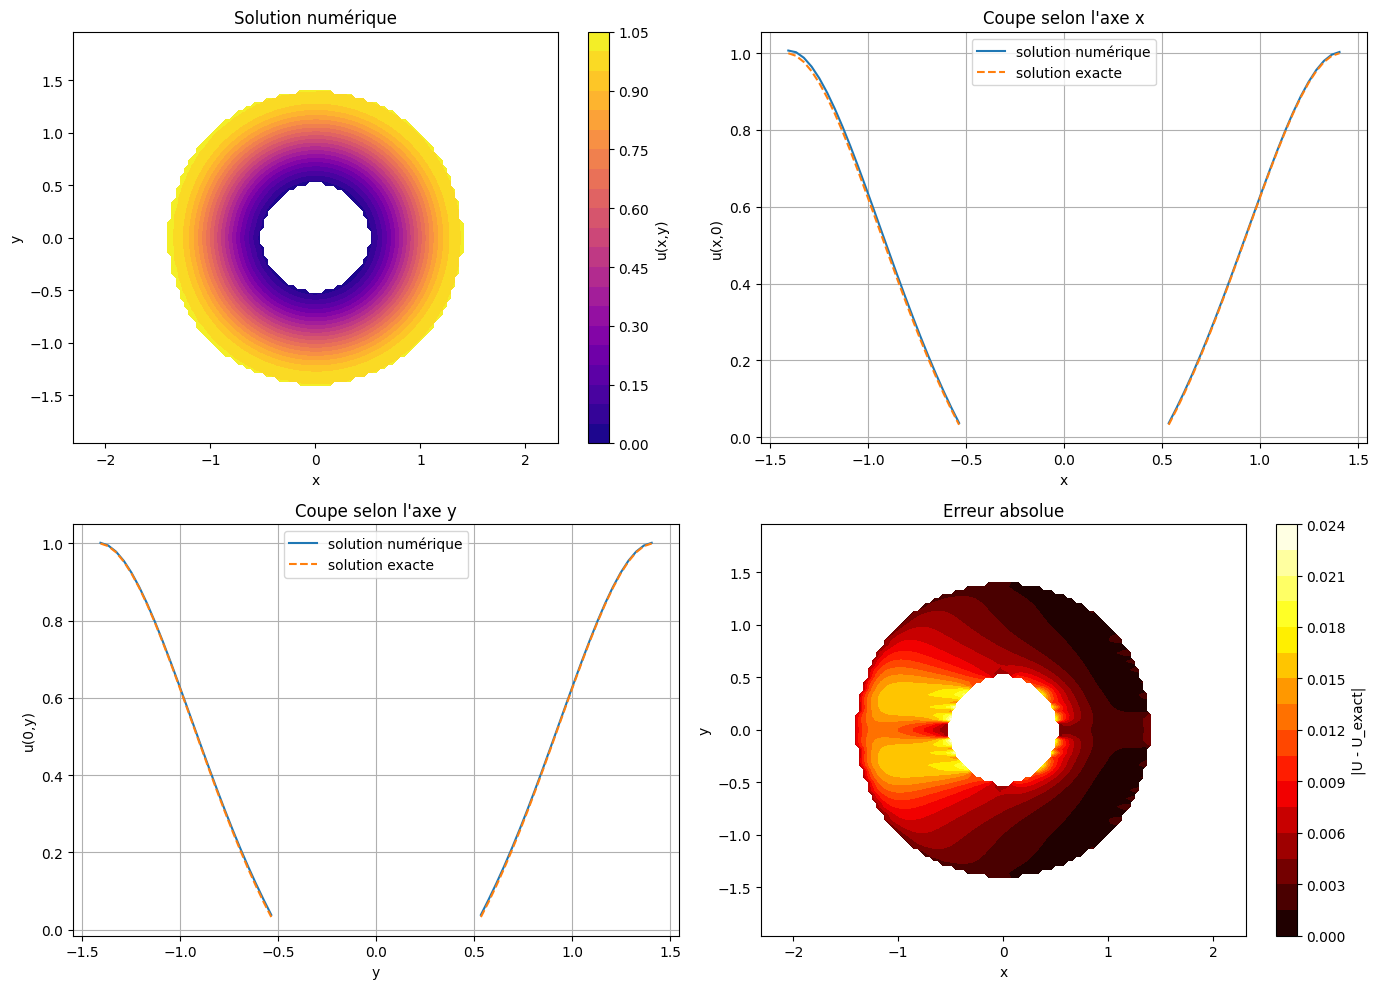

In [ ]:
# paramètres du maillage
config = ZermeloDFConfig(
    M=100,
    X_min=-2,
    X_max=2,
    Y_min=-2,
    Y_max=2,
    max_iter=100,
    tol=1e-5,
    u_ex=True
)

# création du solveur
solver = ZermeloDF(config)

# paramètres physiques
solver.fit(
    r=0.5,
    R=np.sqrt(2),
    kappa=0.1,
    vs=0.5,
    a=0.2,
    sigma_x=0.5,
    sigma_y=0.2
)

# visualisation
solver.plot_solution()

---

<u> Solution exacte inconnue </u>

<u> Solution inexacte : cas vs = 0.5 </u>

/tmp/ipykernel_280/2512312897.py:265: RuntimeWarning: invalid value encountered in divide
  alpha_x = np.where(grad>eps,Ux/grad,0)
/tmp/ipykernel_280/2512312897.py:266: RuntimeWarning: invalid value encountered in divide
  alpha_y = np.where(grad>eps,Uy/grad,0)


Iteration 0  ||U^k+1 - U^k|| = 9.784e+01
Iteration 1  ||U^k+1 - U^k|| = 3.342e+01
Iteration 2  ||U^k+1 - U^k|| = 2.271e+00
Iteration 3  ||U^k+1 - U^k|| = 2.456e-01
Iteration 4  ||U^k+1 - U^k|| = 5.329e-03
Iteration 5  ||U^k+1 - U^k|| = 2.981e-06


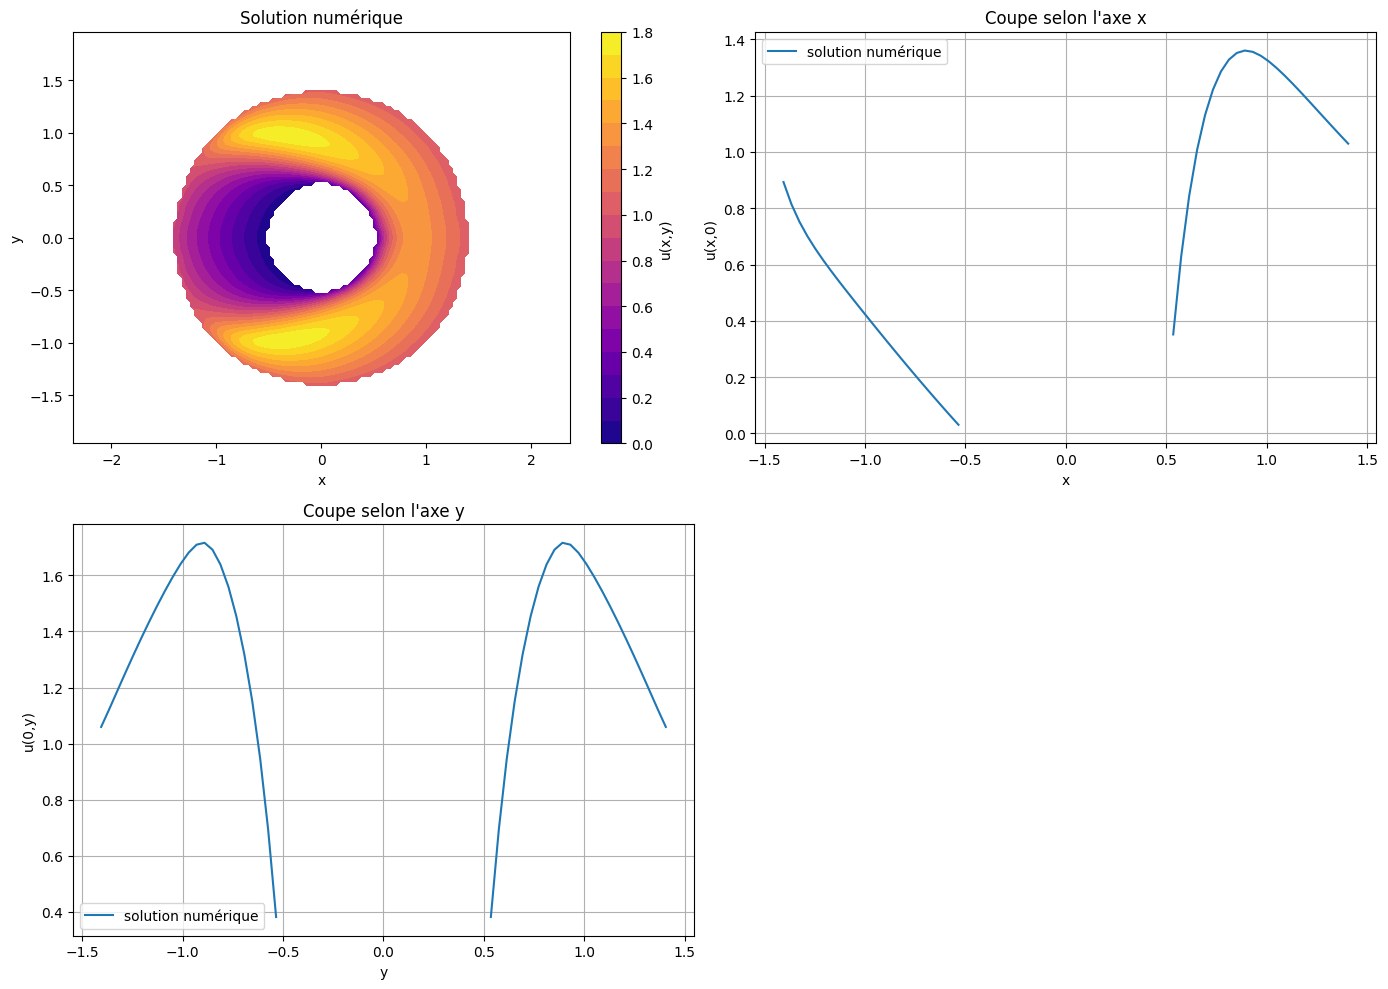

In [ ]:
# paramètres du maillage
config = ZermeloDFConfig(
    M=100,
    X_min=-2,
    X_max=2,
    Y_min=-2,
    Y_max=2,
    max_iter=100,
    tol=1e-5,
    u_ex=False
)

# création du solveur
solver = ZermeloDF(config)

# paramètres physiques
solver.fit(
    r=0.5,
    R=np.sqrt(2),
    kappa=0.1,
    vs=0.5,
    a=0.2,
    sigma_x=0.5,
    sigma_y=0.2
)

# visualisation
solver.plot_solution()

On observe que la difference en valeur absolue entre les itérations décroît rapidement (quelques itérations suffisent). C'est la convergence superlinéaire annoncée dans l'article de reference (Théorème 4.3).

<u> Solution inexacte : cas vs = 1.2 </u>

/tmp/ipykernel_280/2512312897.py:265: RuntimeWarning: invalid value encountered in divide
  alpha_x = np.where(grad>eps,Ux/grad,0)
/tmp/ipykernel_280/2512312897.py:266: RuntimeWarning: invalid value encountered in divide
  alpha_y = np.where(grad>eps,Uy/grad,0)


Iteration 0  ||U^k+1 - U^k|| = 1.914e+02
Iteration 1  ||U^k+1 - U^k|| = 1.010e+02
Iteration 2  ||U^k+1 - U^k|| = 1.918e+01
Iteration 3  ||U^k+1 - U^k|| = 1.157e+01
Iteration 4  ||U^k+1 - U^k|| = 8.661e+00
Iteration 5  ||U^k+1 - U^k|| = 6.496e+00
Iteration 6  ||U^k+1 - U^k|| = 4.596e+00
Iteration 7  ||U^k+1 - U^k|| = 3.131e+00
Iteration 8  ||U^k+1 - U^k|| = 1.924e+00
Iteration 9  ||U^k+1 - U^k|| = 1.011e+00
Iteration 10  ||U^k+1 - U^k|| = 4.392e-01
Iteration 11  ||U^k+1 - U^k|| = 1.192e-01
Iteration 12  ||U^k+1 - U^k|| = 1.031e-02
Iteration 13  ||U^k+1 - U^k|| = 5.809e-05
Iteration 14  ||U^k+1 - U^k|| = 1.465e-09


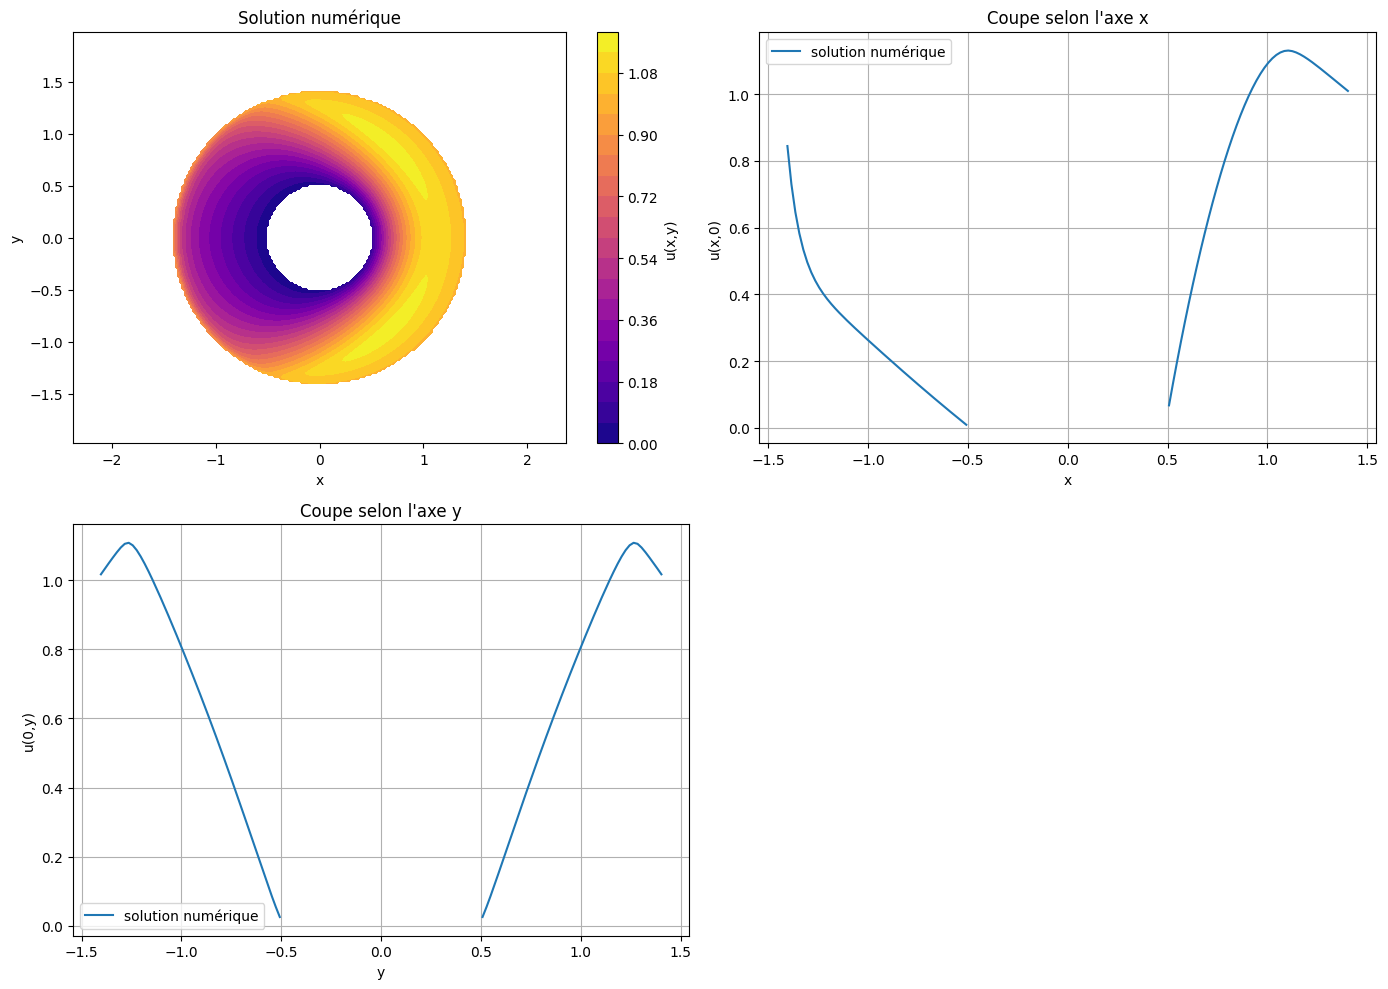

In [ ]:
# paramètres du maillage
config = ZermeloDFConfig(
    M=100,
    X_min=-2,
    X_max=2,
    Y_min=-2,
    Y_max=2,
    max_iter=100,
    tol=1e-5,
    u_ex=False
)

# création du solveur
solver = ZermeloDF(config)

# paramètres physiques
solver.fit(
    r=0.5,
    R=np.sqrt(2),
    kappa=0.1,
    vs=1.2,
    a=0.2,
    sigma_x=0.5,
    sigma_y=0.2
)

# visualisation
solver.plot_solution()

### Etude des ordres de convergence

## Calcul de l'ordre de convergence (Question 3)



In [ ]:
class ZermeloNumericalTestConfig:
    def __init__(self, r: float, R: float, kappa: float, vs: float,
                 a: float, sigma_x: float, sigma_y: float,
                 X_min: float = -2.0, X_max: float = 2.0,
                 Y_min: float = -2.0, Y_max: float = 2.0, u_ex: bool = True):
        # Paramètres physiques
        self.r, self.R = r, R
        self.kappa, self.vs, self.a = kappa, vs, a
        self.sigma_x, self.sigma_y = sigma_x, sigma_y

        # Domaine
        self.X_min, self.X_max = X_min, X_max
        self.Y_min, self.Y_max = Y_min, Y_max
        self.u_ex = u_ex                      # préciser si on a une solution exacte ou non

        # Point d'évaluation de la solution
        mid = self.r + (self.R - self.r) / 2
        self.xy_val = (mid, mid)


class ZermeloNumericalTest:
    """
    Tests de convergence pour ZermeloDF.
    Évalue l'erreur sur omega_int en raffinant la grille.
    """

    def __init__(self, config: ZermeloNumericalTestConfig):
        self.config = config

        # Résultats stockés
        self.result_convergence: pd.DataFrame = None
        self.solvers: List[ZermeloDF] = []

    # Méthode utilitaire : lancer un solver pour un M donné
    def _run_solver(self, M: int) -> Tuple[ZermeloDF, float]:
        """Instancie, ajuste et chronomètre un ZermeloDF."""
        config = ZermeloDFConfig(
            M=M,
            X_min=self.config.X_min, X_max=self.config.X_max,
            Y_min=self.config.Y_min, Y_max=self.config.Y_max,
            u_ex=self.config.u_ex
        )
        solver = ZermeloDF(config)

        start = time.perf_counter()
        solver.fit(self.config.r, self.config.R, self.config.kappa, self.config.vs,
                   self.config.a, self.config.sigma_x, self.config.sigma_y)
        elapsed = time.perf_counter() - start

        return solver, elapsed

    # Test de convergence
    def convergence_test(self, M_list: List[int]) -> pd.DataFrame:
        results = {
            'M': [], 'error': [], 'order_alpha': [], 'tcpu': []
        }
        h_list = []
        err_list = []
        self.solvers = []

        for M in M_list:
            solver, elapsed = self._run_solver(M)
            self.solvers.append(solver)
            U = solver.U
            omega_int = (solver.X**2 + solver.Y**2 > self.config.r**2) & (solver.X**2 + solver.Y**2 < self.config.R**2)

            if self.config.u_ex:
                U_ex = solver.u_exact(solver.X, solver.Y)
                error = (np.abs((U- U_ex)[omega_int])).max()
            elif len(self.solvers) > 1:
                U_prec = np.zeros(U.shape)
                for i in range(M):
                    for j in range(M):
                        if omega_int[i,j]:
                            xy = (solver.X[:,0][i], solver.Y[0,:][j])
                            U_prec[i,j] = self.solvers[-2].interpolate(xy)
                error = (np.abs((U- U_prec)[omega_int])).max()
            else:
                error = 100

            h_list.append(solver.config.h)
            err_list.append(error)

            results['M'].append(M)
            results['error'].append(error)
            results['tcpu'].append(elapsed)

            k = len(err_list)
            if k > 1:
                alpha = (np.log(err_list[-2] / err_list[-1]) /
                         np.log(h_list[-2] / h_list[-1]))
            else:
                alpha = 0.0
            results['order_alpha'].append(alpha)


        self.result_convergence = pd.DataFrame(results)
        return self.result_convergence


    def run_tests(self, M_list: List[int] = None):
        """Lance convergence + stabilité et affiche les résultats."""
        if M_list is None:
            M_list = [20, 40, 80, 160,320]

        print("=" * 55)
        if self.config.u_ex:
            print("  TEST DE CONVERGENCE  (Cas A : solution exacte connue)")
        else:
            print("  TEST DE CONVERGENCE  (Cas B : f = 1 et solution exacte inconnue)")
        print("=" * 55)
        df_conv = self.convergence_test(M_list)
        print(df_conv)





<u> Cas de la solution exacte </u>

In [ ]:
# Paramètres donnés
r = 0.5
R = np.sqrt(2)  # environ 1.4142135623730951
kappa = 0.1
vs = 0.5
a = 0.2
sigma_x = 0.5
sigma_y = 0.2

# Liste des maillages pour le test de convergence
M_list = [20, 40, 80, 160, 320]

print("="*80)
print("CAS 1 : TEST DE CONVERGENCE AVEC SOLUTION EXACTE")
print("="*80)
print(f"Paramètres :")
print(f"  r = {r}")
print(f"  R = {R:.6f}")
print(f"  kappa = {kappa}")
print(f"  vs = {vs}")
print(f"  a = {a}")
print(f"  sigma_x = {sigma_x}")
print(f"  sigma_y = {sigma_y}")
print("="*80)

# Configuration
config_exact = ZermeloNumericalTestConfig(
    r=r, R=R, kappa=kappa, vs=vs,
    a=a, sigma_x=sigma_x, sigma_y=sigma_y,
    u_ex=True,
    X_min=-2.0, X_max=2.0,
    Y_min=-2.0, Y_max=2.0
)

# Lancer le test
test_exact = ZermeloNumericalTest(config_exact)
test_exact.run_tests(M_list)

# Afficher les résultats détaillés
print("\n" + "-"*80)
print("RÉSULTATS DÉTAILLÉS :")
print("-"*80)
print(test_exact.result_convergence.to_string(float_format='{:.6e}'.format, index=False))


# Sauvegarder les résultats
test_exact.result_convergence.to_csv("convergence_exact_solution.csv", index=False)
print("\n✓ Résultats sauvegardés dans 'convergence_exact_solution.csv'")

CAS 1 : TEST DE CONVERGENCE AVEC SOLUTION EXACTE
Paramètres :
  r = 0.5
  R = 1.414214
  kappa = 0.1
  vs = 0.5
  a = 0.2
  sigma_x = 0.5
  sigma_y = 0.2
  TEST DE CONVERGENCE  (Cas A : solution exacte connue)
Iteration 0  ||U^k+1 - U^k|| = 1.393e+01
Iteration 1  ||U^k+1 - U^k|| = 5.369e+00
Iteration 2  ||U^k+1 - U^k|| = 6.870e-01
Iteration 3  ||U^k+1 - U^k|| = 3.272e-02
Iteration 4  ||U^k+1 - U^k|| = 2.040e-04


/tmp/ipykernel_280/2512312897.py:265: RuntimeWarning: invalid value encountered in divide
  alpha_x = np.where(grad>eps,Ux/grad,0)
/tmp/ipykernel_280/2512312897.py:266: RuntimeWarning: invalid value encountered in divide
  alpha_y = np.where(grad>eps,Uy/grad,0)


Iteration 0  ||U^k+1 - U^k|| = 2.545e+01
Iteration 1  ||U^k+1 - U^k|| = 9.356e+00
Iteration 2  ||U^k+1 - U^k|| = 1.227e+00
Iteration 3  ||U^k+1 - U^k|| = 2.602e-01
Iteration 4  ||U^k+1 - U^k|| = 1.116e-02
Iteration 5  ||U^k+1 - U^k|| = 9.691e-05
Iteration 0  ||U^k+1 - U^k|| = 4.911e+01
Iteration 1  ||U^k+1 - U^k|| = 1.719e+01
Iteration 2  ||U^k+1 - U^k|| = 2.483e+00
Iteration 3  ||U^k+1 - U^k|| = 5.480e-01
Iteration 4  ||U^k+1 - U^k|| = 1.065e-01
Iteration 5  ||U^k+1 - U^k|| = 1.011e-02
Iteration 6  ||U^k+1 - U^k|| = 1.133e-04
Iteration 0  ||U^k+1 - U^k|| = 9.601e+01
Iteration 1  ||U^k+1 - U^k|| = 3.314e+01
Iteration 2  ||U^k+1 - U^k|| = 4.930e+00
Iteration 3  ||U^k+1 - U^k|| = 1.088e+00
Iteration 4  ||U^k+1 - U^k|| = 2.153e-01
Iteration 5  ||U^k+1 - U^k|| = 3.023e-02
Iteration 6  ||U^k+1 - U^k|| = 3.029e-03
Iteration 7  ||U^k+1 - U^k|| = 8.018e-06
Iteration 0  ||U^k+1 - U^k|| = 1.902e+02
Iteration 1  ||U^k+1 - U^k|| = 6.532e+01
Iteration 2  ||U^k+1 - U^k|| = 9.771e+00
Iteration 3  ||U

<u> Cas avec solution inconnue </u>

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Paramètres donnés
r = 0.5
R = np.sqrt(2)  # environ 1.4142135623730951
kappa = 0.1
vs = 0.5
a = 0.2
sigma_x = 0.5
sigma_y = 0.2

# Liste des maillages pour le test de convergence
M_list = [20, 40, 80, 160, 320]

print("="*80)
print("CAS 2 : TEST DE CONVERGENCE SANS SOLUTION EXACTE")
print("="*80)
print(f"Paramètres :")
print(f"  r = {r}")
print(f"  R = {R:.6f}")
print(f"  kappa = {kappa}")
print(f"  vs = {vs}")
print(f"  a = {a}")
print(f"  sigma_x = {sigma_x}")
print(f"  sigma_y = {sigma_y}")
print("="*80)

# Configuration
config_inexact = ZermeloNumericalTestConfig(
    r=r, R=R, kappa=kappa, vs=vs,
    a=a, sigma_x=sigma_x, sigma_y=sigma_y,
    u_ex=False,
    X_min=-2.0, X_max=2.0,
    Y_min=-2.0, Y_max=2.0
)

# Lancer le test
test_inexact = ZermeloNumericalTest(config_inexact)
test_inexact.run_tests(M_list)

# Afficher les résultats détaillés
print("\n" + "-"*80)
print("RÉSULTATS DÉTAILLÉS :")
print("-"*80)
print(test_inexact.result_convergence.to_string(float_format='{:.6e}'.format, index=False))


# Sauvegarder les résultats
test_inexact.result_convergence.to_csv("convergence_no_exact_solution.csv", index=False)
print("\n✓ Résultats sauvegardés dans 'convergence_no_exact_solution.csv'")

CAS 2 : TEST DE CONVERGENCE SANS SOLUTION EXACTE
Paramètres :
  r = 0.5
  R = 1.414214
  kappa = 0.1
  vs = 0.5
  a = 0.2
  sigma_x = 0.5
  sigma_y = 0.2
  TEST DE CONVERGENCE  (Cas B : f = 1 et solution exacte inconnue)
Iteration 0  ||U^k+1 - U^k|| = 2.502e+01
Iteration 1  ||U^k+1 - U^k|| = 1.046e+01
Iteration 2  ||U^k+1 - U^k|| = 5.751e-01
Iteration 3  ||U^k+1 - U^k|| = 6.169e-03
Iteration 4  ||U^k+1 - U^k|| = 3.250e-06


/tmp/ipykernel_280/2512312897.py:265: RuntimeWarning: invalid value encountered in divide
  alpha_x = np.where(grad>eps,Ux/grad,0)
/tmp/ipykernel_280/2512312897.py:266: RuntimeWarning: invalid value encountered in divide
  alpha_y = np.where(grad>eps,Uy/grad,0)


Iteration 0  ||U^k+1 - U^k|| = 4.297e+01
Iteration 1  ||U^k+1 - U^k|| = 1.574e+01
Iteration 2  ||U^k+1 - U^k|| = 9.234e-01
Iteration 3  ||U^k+1 - U^k|| = 4.405e-02
Iteration 4  ||U^k+1 - U^k|| = 1.208e-04
Iteration 0  ||U^k+1 - U^k|| = 7.913e+01
Iteration 1  ||U^k+1 - U^k|| = 2.744e+01
Iteration 2  ||U^k+1 - U^k|| = 1.922e+00
Iteration 3  ||U^k+1 - U^k|| = 2.380e-01
Iteration 4  ||U^k+1 - U^k|| = 3.109e-03
Iteration 5  ||U^k+1 - U^k|| = 8.251e-07
Iteration 0  ||U^k+1 - U^k|| = 1.531e+02
Iteration 1  ||U^k+1 - U^k|| = 5.203e+01
Iteration 2  ||U^k+1 - U^k|| = 3.687e+00
Iteration 3  ||U^k+1 - U^k|| = 4.626e-01
Iteration 4  ||U^k+1 - U^k|| = 2.828e-02
Iteration 5  ||U^k+1 - U^k|| = 5.181e-05
Iteration 0  ||U^k+1 - U^k|| = 3.020e+02
Iteration 1  ||U^k+1 - U^k|| = 1.020e+02
Iteration 2  ||U^k+1 - U^k|| = 7.312e+00
Iteration 3  ||U^k+1 - U^k|| = 1.032e+00
Iteration 4  ||U^k+1 - U^k|| = 6.798e-02
Iteration 5  ||U^k+1 - U^k|| = 5.052e-04
     M       error  order_alpha       tcpu
0   20  100.00